# Session 4 – Monte Carlo Simulation II
### Risk Modelling: Advanced Techniques & Applications

**Topics covered:**
1. Latin Hypercube Sampling
2. Modelling Correlated Variables
3. Risk Tornado Diagrams
4. Risk Scenario Analysis
5. Simulating Stock Prices with GBM (live data from Yahoo Finance)
6. Bootstrapping / Resampling
7. Value at Risk (VaR)

In [1]:
# ── Install / import dependencies ─────────────────────────────────────────
# Run this cell first; uncomment the pip lines if packages are missing
# !pip install yfinance numpy pandas scipy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
import yfinance as yf

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Matplotlib style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.edgecolor':   '#cccccc',
    'axes.grid':        True,
    'grid.color':       '#eeeeee',
    'grid.linewidth':   0.7,
    'font.size':        12,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'figure.dpi':       110,
})

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 1. Latin Hypercube Sampling

**Idea:** Divide the cumulative distribution function (CDF) into $N$ equally probable intervals and draw exactly one sample from each interval. This avoids the clustering that occurs with purely random (Monte Carlo) sampling and produces a more representative distribution with fewer iterations.

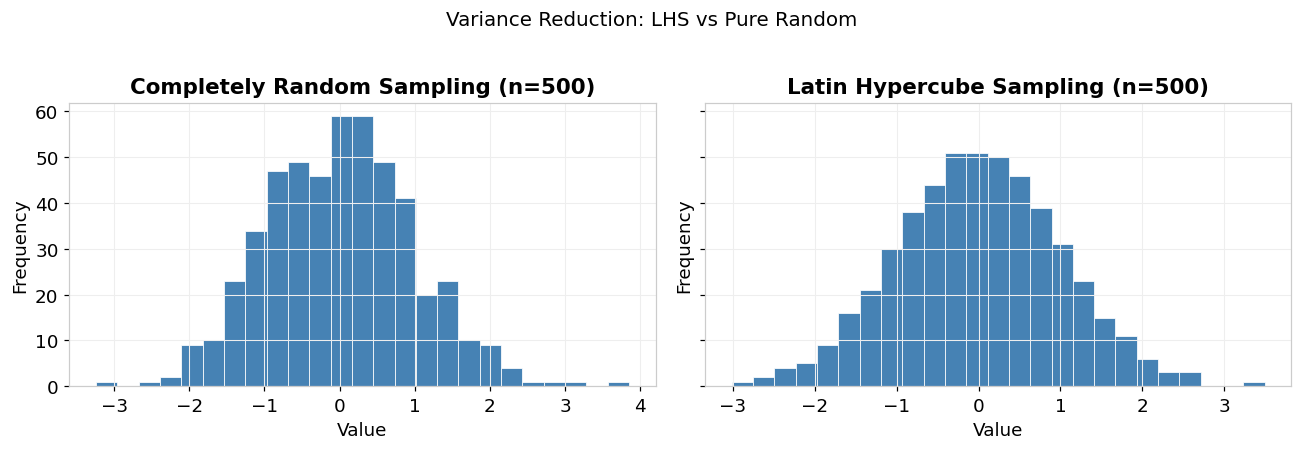

Random  – mean: 0.0068  std: 0.9803
LHS     – mean: 0.0011    std: 1.0016
Theoretical  – mean: 0.0000  std: 1.0000


In [2]:
def latin_hypercube_normal(n: int, mu: float = 0.0, sigma: float = 1.0) -> np.ndarray:
    """Draw n LHS samples from Normal(mu, sigma)."""
    # Divide [0,1] into n equal-probability bins
    # Sample one point uniformly within each bin, then shuffle
    bin_edges = np.arange(n) / n
    u = bin_edges + np.random.uniform(0, 1/n, size=n)   # one sample per bin
    np.random.shuffle(u)                                   # break any ordering
    return stats.norm.ppf(u, loc=mu, scale=sigma)          # inverse CDF transform


def pure_random_normal(n: int, mu: float = 0.0, sigma: float = 1.0) -> np.ndarray:
    return np.random.normal(mu, sigma, size=n)


N = 500
random_samples = pure_random_normal(N)
lhs_samples    = latin_hypercube_normal(N)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, data, title in zip(axes,
                            [random_samples, lhs_samples],
                            ['Completely Random Sampling (n=500)',
                             'Latin Hypercube Sampling (n=500)']):
    ax.hist(data, bins=25, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.suptitle('Variance Reduction: LHS vs Pure Random', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Random  – mean: {random_samples.mean():.4f}  std: {random_samples.std():.4f}')
print(f'LHS     – mean: {lhs_samples.mean():.4f}    std: {lhs_samples.std():.4f}')
print(f'Theoretical  – mean: 0.0000  std: 1.0000')

---
## 2. Modelling Correlated Variables

When input variables are correlated, ignoring the correlation leads to incorrect risk estimates.  
We implement the **Iman–Conover method**: generate independent samples, rank them, then rearrange to match a target rank-correlation structure.

Statistic                     Corr=0       Corr=-0.8
----------------------------------------------------
Mean                         9,996.7         9,683.4
Median                       9,817.0         9,682.6
Std Dev                      2,819.6         1,349.0
Min                          1,513.0         2,789.2
Max                         22,654.8        14,840.4


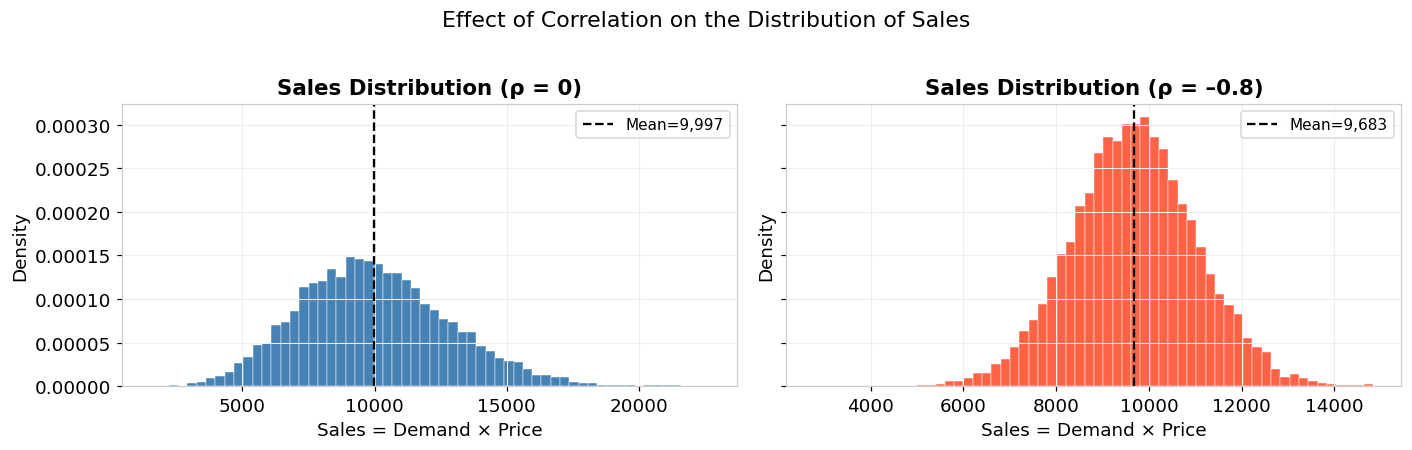

In [3]:
def iman_conover(samples: np.ndarray, corr_matrix: np.ndarray) -> np.ndarray:
    """
    Rearrange columns of `samples` so that their rank correlations
    approximate `corr_matrix` (Iman-Conover method).

    Parameters
    ----------
    samples    : (n_obs, n_vars) array of independently drawn samples
    corr_matrix: target Spearman correlation matrix (n_vars x n_vars)

    Returns
    -------
    correlated : rearranged samples with approximately the desired correlations
    """
    n, k = samples.shape
    # Step 1: convert samples to scores (van der Waerden scores)
    scores = np.zeros_like(samples)
    for j in range(k):
        ranks = stats.rankdata(samples[:, j])
        scores[:, j] = stats.norm.ppf(ranks / (n + 1))

    # Step 2: Cholesky decomposition of target correlation matrix
    P = np.linalg.cholesky(corr_matrix)
    # Step 3: Cholesky of current score correlation
    Q = np.linalg.cholesky(np.corrcoef(scores, rowvar=False))
    # Step 4: apply transformation to scores
    T = scores @ np.linalg.inv(Q).T @ P.T

    # Step 5: reorder each column of samples by the new ranking of T
    correlated = np.zeros_like(samples)
    for j in range(k):
        order = np.argsort(np.argsort(T[:, j]))   # rank order
        sorted_col = np.sort(samples[:, j])
        correlated[:, j] = sorted_col[order]

    return correlated


# ── Simulation ────────────────────────────────────────────────────────────
N_SIM = 10_000
MU, SIGMA = 100, 20

# Draw independent samples for Demand and Price
raw = np.column_stack([
    np.random.normal(MU, SIGMA, N_SIM),
    np.random.normal(MU, SIGMA, N_SIM),
])

# Target correlation matrix (rho = -0.8)
target_corr = np.array([[1.0, -0.8],
                         [-0.8, 1.0]])

corr_samples = iman_conover(raw.copy(), target_corr)

# Sales = Demand * Price
sales_uncorr = raw[:, 0] * raw[:, 1]
sales_corr   = corr_samples[:, 0] * corr_samples[:, 1]

# ── Summary stats ─────────────────────────────────────────────────────────
print(f'{"Statistic":20s} {"Corr=0":>15s} {"Corr=-0.8":>15s}')
print('-' * 52)
for label, fn in [("Mean",    np.mean), ("Median",  np.median),
                   ("Std Dev", np.std),  ("Min",     np.min), ("Max",  np.max)]:
    print(f'{label:20s} {fn(sales_uncorr):15,.1f} {fn(sales_corr):15,.1f}')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, data, label, colour in zip(
        axes,
        [sales_uncorr, sales_corr],
        ['Sales Distribution (ρ = 0)', 'Sales Distribution (ρ = –0.8)'],
        ['steelblue', 'tomato']):
    ax.hist(data, bins=60, color=colour, edgecolor='white', linewidth=0.3, density=True)
    ax.set_title(label)
    ax.set_xlabel('Sales = Demand × Price')
    ax.set_ylabel('Density')
    ax.axvline(np.mean(data), color='black', linewidth=1.5, linestyle='--', label=f'Mean={np.mean(data):,.0f}')
    ax.legend(fontsize=10)

plt.suptitle('Effect of Correlation on the Distribution of Sales', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Risk Tornado Diagram

Compute the Pearson correlation between each input variable and the output (NPV), sort by absolute value, and plot as a horizontal bar chart.

                  Correlation   AbsCorr
Var Cost %          -0.231142  0.231142
Initial Fare         0.355039  0.355039
Pass. Multiplier     0.616406  0.616406
Fare Increase %      0.652643  0.652643


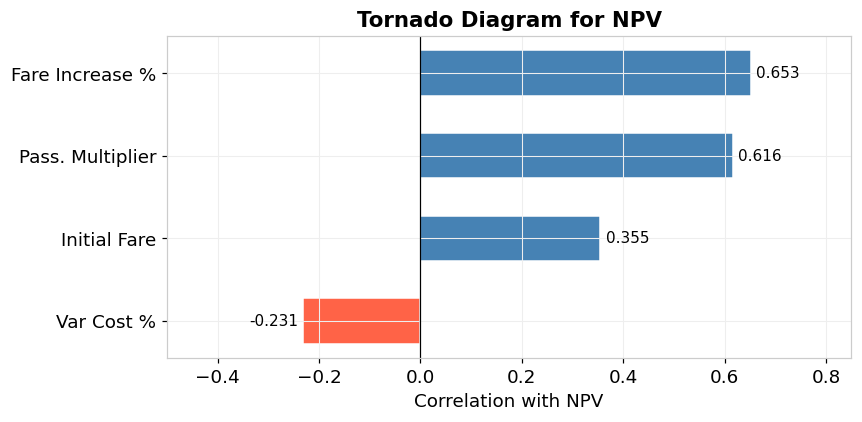

In [4]:
# ── Synthetic LEA airline NPV simulation ──────────────────────────────────
# We create a simplified NPV model for illustration.
# All inputs are drawn independently.

N_SIM = 10_000
rng = np.random.default_rng(0)

# Input distributions (triangular parameterised as (low, mode, high))
def triang(low, mode, high, n):
    c = (mode - low) / (high - low)
    return stats.triang.rvs(c, loc=low, scale=high-low, size=n)

pass_mult     = rng.normal(1.0, 0.10, N_SIM)          # passenger multiplier
init_fare     = triang(57, 73, 75, N_SIM)              # £/ticket
fare_increase = triang(0.00, 0.08, 0.10, N_SIM)       # annual %
var_cost_pct  = triang(0.10, 0.14, 0.25, N_SIM)       # % of revenue

# Simplified NPV formula
YEARS, BASE_PSGR, DISC_RATE = 10, 100_000, 0.08
npv = np.zeros(N_SIM)
for t in range(1, YEARS + 1):
    revenue = pass_mult * BASE_PSGR * init_fare * (1 + fare_increase)**t
    costs   = revenue * var_cost_pct
    npv    += (revenue - costs) / (1 + DISC_RATE)**t
npv -= 5_000_000  # initial investment

# ── Compute Pearson correlations ──────────────────────────────────────────
inputs = {
    'Var Cost %':       var_cost_pct,
    'Initial Fare':     init_fare,
    'Fare Increase %':  fare_increase,
    'Pass. Multiplier': pass_mult,
}

corrs = {name: np.corrcoef(vals, npv)[0, 1] for name, vals in inputs.items()}
corr_df = (pd.DataFrame.from_dict(corrs, orient='index', columns=['Correlation'])
             .assign(AbsCorr=lambda x: x['Correlation'].abs())
             .sort_values('AbsCorr'))

print(corr_df.to_string())

# ── Tornado diagram ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colours = ['tomato' if v < 0 else 'steelblue' for v in corr_df['Correlation']]
bars = ax.barh(corr_df.index, corr_df['Correlation'], color=colours, edgecolor='white', height=0.55)
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, corr_df['Correlation']):
    xpos = val + (0.01 if val >= 0 else -0.01)
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)
ax.set_xlabel('Correlation with NPV')
ax.set_title('Tornado Diagram for NPV')
ax.set_xlim(-0.5, 0.85)
plt.tight_layout()
plt.show()

---
## 4. Risk Scenario Analysis

Filter simulation results by an output condition (e.g. NPV < 0) and compare the conditional median of each input to the overall median, normalised by its standard deviation.

In [5]:
sim_df = pd.DataFrame({
    'PassMult':    pass_mult,
    'InitFare':    init_fare,
    'FareIncrease':fare_increase,
    'VarCost':     var_cost_pct,
    'NPV':         npv,
})

def scenario_analysis(df: pd.DataFrame,
                       condition,
                       input_cols: list,
                       label: str = '') -> pd.DataFrame:
    """
    Compares conditional median of each input to the overall median.

    Returns a DataFrame with columns:
      Overall Median | Conditional Median | Std Dev | Δ (std devs)
    """
    filtered = df[condition]
    result = []
    for col in input_cols:
        med_all  = df[col].median()
        med_filt = filtered[col].median()
        std_all  = df[col].std()
        delta    = (med_filt - med_all) / std_all
        result.append({'Variable':         col,
                        'Overall Median':  round(med_all,  4),
                        'Cond. Median':    round(med_filt, 4),
                        'Std Dev':         round(std_all,  4),
                        'Δ (std devs)':    round(delta,    3),
                        '|Δ|':             round(abs(delta),3)})
    out = pd.DataFrame(result).set_index('Variable').sort_values('|Δ|', ascending=False)
    n_filtered = condition.sum()
    print(f'\n{label}  –  {n_filtered:,} iterations out of {len(df):,} match the condition')
    return out

INPUT_COLS = ['PassMult', 'InitFare', 'FareIncrease', 'VarCost']

scenario_neg = scenario_analysis(sim_df, sim_df['NPV'] < 0, INPUT_COLS, 'NPV < 0')
print(scenario_neg.to_string())

scenario_pos = scenario_analysis(sim_df, sim_df['NPV'] > 5_000_000, INPUT_COLS, 'NPV > 5,000,000')
print(scenario_pos.to_string())

# ── Highlight |Δ| > 0.5 ──────────────────────────────────────────────────
print('\nVariables with |Δ| > 0.5 when NPV < 0 (flagged as risk drivers):')
print(scenario_neg[scenario_neg['|Δ|'] > 0.5][['Overall Median','Cond. Median','Δ (std devs)']])


NPV < 0  –  0 iterations out of 10,000 match the condition
              Overall Median  Cond. Median  Std Dev  Δ (std devs)  |Δ|
Variable                                                              
PassMult              0.9991           NaN   0.0998           NaN  NaN
InitFare             69.0407           NaN   4.0296           NaN  NaN
FareIncrease          0.0632           NaN   0.0215           NaN  NaN
VarCost               0.1596           NaN   0.0316           NaN  NaN

NPV > 5,000,000  –  10,000 iterations out of 10,000 match the condition
              Overall Median  Cond. Median  Std Dev  Δ (std devs)  |Δ|
Variable                                                              
PassMult              0.9991        0.9991   0.0998           0.0  0.0
InitFare             69.0407       69.0407   4.0296           0.0  0.0
FareIncrease          0.0632        0.0632   0.0215           0.0  0.0
VarCost               0.1596        0.1596   0.0316           0.0  0.0

Variables with

---
## 5. Simulating Stock Prices

We download **5 years** of daily adjusted close prices from Yahoo Finance, estimate the GBM parameters ($\mu$, $\sigma$), and simulate future price paths.

  Date range: 2021-03-01 → 2026-02-27
  Trading days: 1,256
  Latest close: $177.76

  Annualised drift (μ):      51.31%
  Annualised volatility (σ): 51.57%
  Starting price (S0):       $177.76


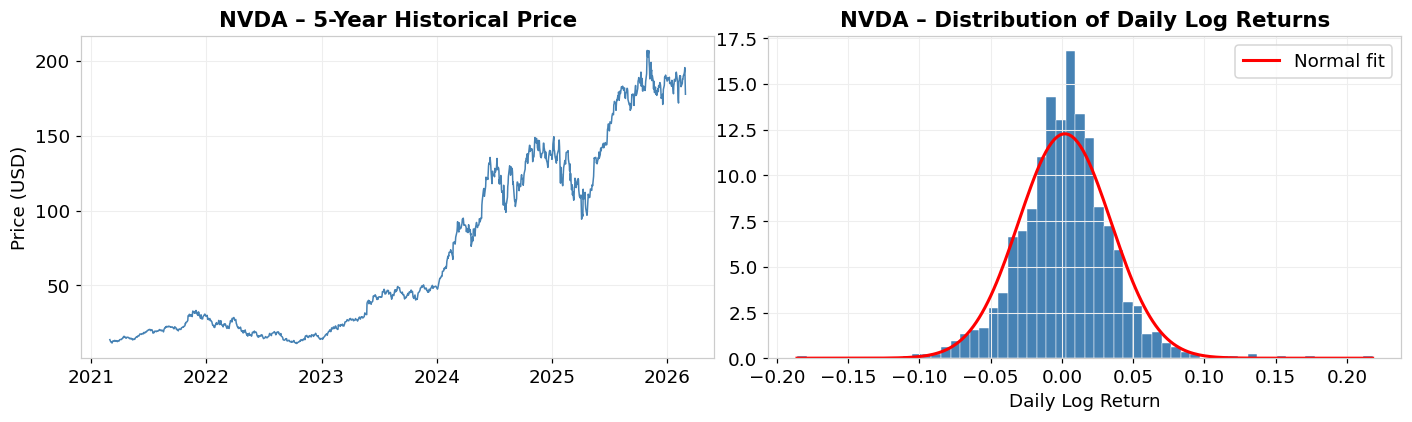

In [7]:
# ── Download 5 years of daily price data ──────────────────────────────────
TICKER = 'NVDA'   # Change to any ticker

print(f'Downloading 5 years of daily data for {TICKER} from Yahoo Finance...')
ticker_obj = yf.Ticker(TICKER)
price_data = ticker_obj.history(period='5y')
prices = price_data['Close'].dropna()

print(f'  Date range: {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'  Trading days: {len(prices):,}')
print(f'  Latest close: ${prices.iloc[-1]:.2f}')

# ── Compute log returns and calibrate GBM ─────────────────────────────────
log_returns = np.log(prices / prices.shift(1)).dropna()

TRADING_DAYS = 252
mu_daily    = log_returns.mean()
sigma_daily = log_returns.std()
mu_annual   = mu_daily * TRADING_DAYS
sigma_annual= sigma_daily * np.sqrt(TRADING_DAYS)
S0          = prices.iloc[-1]

print(f'\n  Annualised drift (μ):      {mu_annual:.2%}')
print(f'  Annualised volatility (σ): {sigma_annual:.2%}')
print(f'  Starting price (S0):       ${S0:.2f}')

# ── Plot historical prices and log returns ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(prices.index, prices.values, color='steelblue', linewidth=1)
axes[0].set_title(f'{TICKER} – 5-Year Historical Price')
axes[0].set_ylabel('Price (USD)')

axes[1].hist(log_returns, bins=60, color='steelblue', edgecolor='white', linewidth=0.3, density=True)
x = np.linspace(log_returns.min(), log_returns.max(), 200)
axes[1].plot(x, stats.norm.pdf(x, mu_daily, sigma_daily), 'r-', linewidth=2, label='Normal fit')
axes[1].set_title(f'{TICKER} – Distribution of Daily Log Returns')
axes[1].set_xlabel('Daily Log Return')
axes[1].legend()

plt.tight_layout()
plt.show()

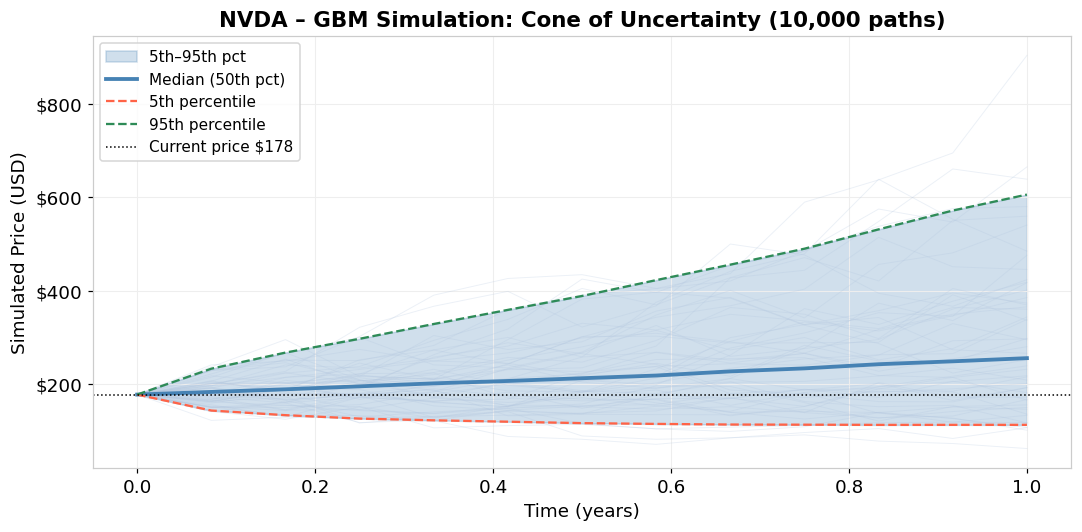


At the 1-year horizon (10,000 simulations):
  5th  percentile: $  112.93
  Median:          $  255.74
  95th percentile: $  606.06


In [8]:
# ── GBM Monte Carlo simulation – cone of uncertainty ─────────────────────

N_PATHS = 10_000
N_STEPS = 12          # monthly steps over 1 year
DT = 1 / N_STEPS      # fraction of year per step

# Simulate all paths at once (vectorised)
shocks = np.random.randn(N_PATHS, N_STEPS)         # (paths, steps)
log_increments = (mu_annual - 0.5 * sigma_annual**2) * DT \
               + sigma_annual * np.sqrt(DT) * shocks

# Cumulative product starting from S0
price_paths = S0 * np.exp(np.cumsum(log_increments, axis=1))  # (paths, steps)
price_paths = np.hstack([np.full((N_PATHS, 1), S0), price_paths])  # prepend S0

times = np.linspace(0, 1, N_STEPS + 1)
p5, p50, p95 = np.percentile(price_paths, [5, 50, 95], axis=0)

# Plot cone of uncertainty
fig, ax = plt.subplots(figsize=(10, 5))

# Plot a handful of sample paths for intuition
for path in price_paths[:50]:
    ax.plot(times, path, color='lightsteelblue', alpha=0.25, linewidth=0.6)

ax.fill_between(times, p5, p95, alpha=0.25, color='steelblue', label='5th–95th pct')
ax.plot(times, p50, 'steelblue',  linewidth=2.5, label='Median (50th pct)')
ax.plot(times, p5,  'tomato',     linewidth=1.5, linestyle='--', label='5th percentile')
ax.plot(times, p95, 'seagreen',   linewidth=1.5, linestyle='--', label='95th percentile')
ax.axhline(S0, color='black', linewidth=1, linestyle=':', label=f'Current price ${S0:.0f}')

ax.set_title(f'{TICKER} – GBM Simulation: Cone of Uncertainty ({N_PATHS:,} paths)')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Simulated Price (USD)')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.show()

print(f'\nAt the 1-year horizon ({N_PATHS:,} simulations):')
print(f'  5th  percentile: ${p5[-1]:>8,.2f}')
print(f'  Median:          ${p50[-1]:>8,.2f}')
print(f'  95th percentile: ${p95[-1]:>8,.2f}')

---
## 6. Bootstrapping / Resampling

Instead of fitting a distribution, we sample directly from historical log returns. This naturally preserves fat tails, skewness, and any other non-normal features of the empirical distribution.

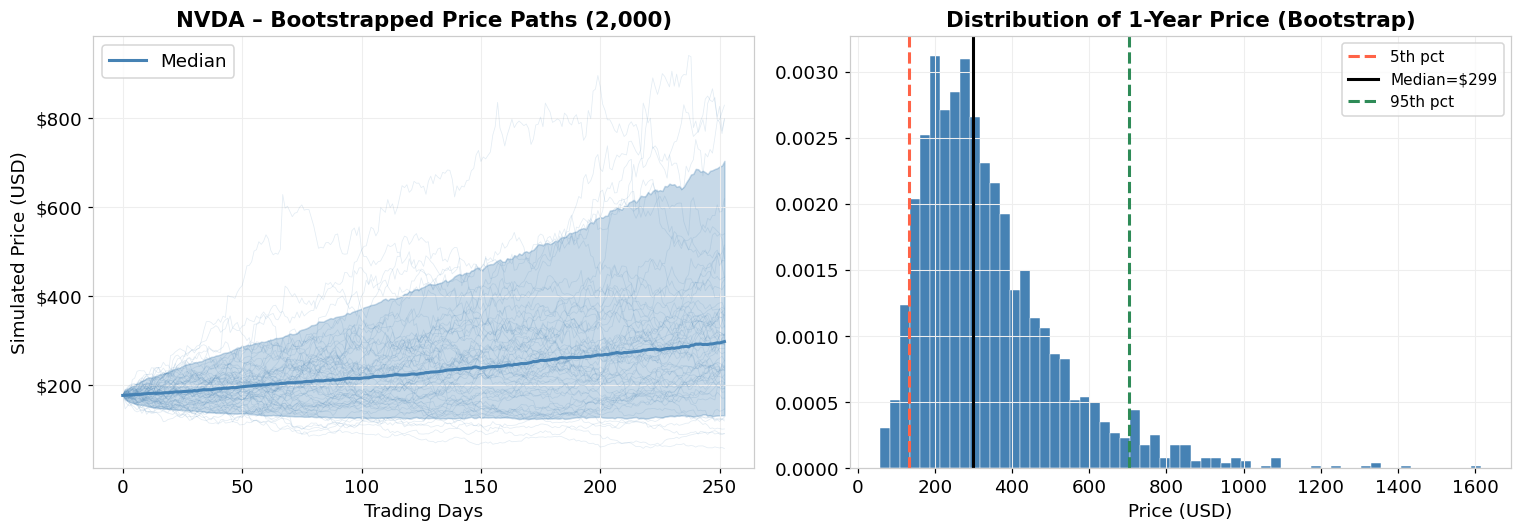

In [9]:
# ── Bootstrapped stock price simulation ───────────────────────────────────

log_returns_arr = log_returns.values

def bootstrap_path(S0: float, n_steps: int, hist_returns: np.ndarray) -> np.ndarray:
    """Simulate one price path by resampling from historical log returns."""
    drawn = np.random.choice(hist_returns, size=n_steps, replace=True)
    path  = S0 * np.exp(np.cumsum(drawn))
    return np.concatenate([[S0], path])


N_PATHS_BS = 2_000
N_DAYS     = 252

bs_paths = np.array([bootstrap_path(S0, N_DAYS, log_returns_arr)
                     for _ in range(N_PATHS_BS)])

days_arr = np.arange(N_DAYS + 1)
bp5, bp50, bp95 = np.percentile(bs_paths, [5, 50, 95], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price paths
for path in bs_paths[:60]:
    axes[0].plot(days_arr, path, color='steelblue', alpha=0.15, linewidth=0.5)
axes[0].fill_between(days_arr, bp5, bp95, alpha=0.3, color='steelblue')
axes[0].plot(days_arr, bp50, 'steelblue', linewidth=2, label='Median')
axes[0].set_title(f'{TICKER} – Bootstrapped Price Paths ({N_PATHS_BS:,})')
axes[0].set_xlabel('Trading Days')
axes[0].set_ylabel('Simulated Price (USD)')
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
axes[0].legend()

# Distribution of 1-year prices
one_year = bs_paths[:, -1]
axes[1].hist(one_year, bins=60, color='steelblue', edgecolor='white', linewidth=0.3, density=True)
axes[1].axvline(np.percentile(one_year, 5),  color='tomato',  linewidth=2, linestyle='--', label='5th pct')
axes[1].axvline(np.median(one_year),         color='black',   linewidth=2, label=f'Median=${np.median(one_year):,.0f}')
axes[1].axvline(np.percentile(one_year, 95), color='seagreen',linewidth=2, linestyle='--', label='95th pct')
axes[1].set_title('Distribution of 1-Year Price (Bootstrap)')
axes[1].set_xlabel('Price (USD)')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

Sample median daily log return: 0.002835
95% Bootstrap CI:               [0.000911,  0.004441]


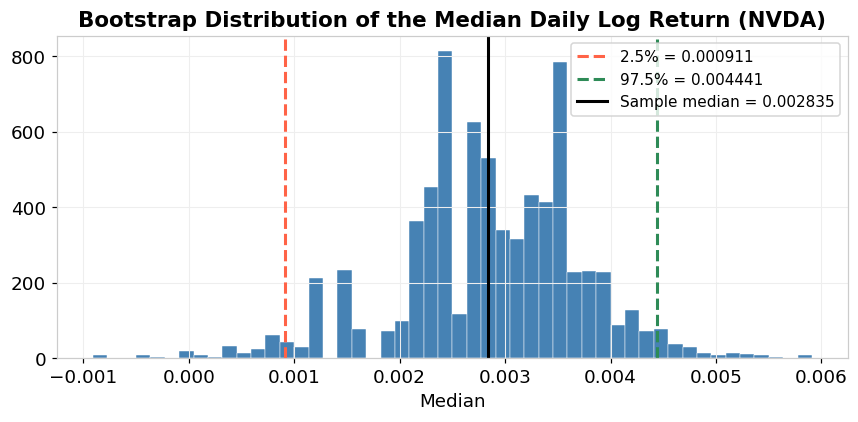

In [11]:
# ── Bootstrap confidence interval for the median ──────────────────────────
# Example: construct a 95% CI for the median daily log return

def bootstrap_ci(data: np.ndarray,
                  statistic = np.median,
                  n_boot: int = 2000,
                  ci: float = 95.0) -> tuple:
    """
    Non-parametric bootstrap confidence interval.

    Returns
    -------
    (lower, upper, boot_statistics)
    """
    boot_stats = np.array([
        statistic(np.random.choice(data, size=len(data), replace=True))
        for _ in range(n_boot)
    ])
    alpha = (100 - ci) / 2
    lower, upper = np.percentile(boot_stats, [alpha, 100 - alpha])
    return lower, upper, boot_stats


lower, upper, boot_medians = bootstrap_ci(log_returns_arr, np.median, n_boot=2000)
sample_median = np.median(log_returns_arr)

print(f'Sample median daily log return: {sample_median:.6f}')
print(f'95% Bootstrap CI:               [{lower:.6f},  {upper:.6f}]')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_medians, bins=50, color='steelblue', edgecolor='white', linewidth=0.3, density=True)
ax.axvline(lower,         color='tomato',  linewidth=2, linestyle='--', label=f'2.5% = {lower:.6f}')
ax.axvline(upper,         color='seagreen',linewidth=2, linestyle='--', label=f'97.5% = {upper:.6f}')
ax.axvline(sample_median, color='black',   linewidth=2, label=f'Sample median = {sample_median:.6f}')
ax.set_title(f'Bootstrap Distribution of the Median Daily Log Return ({TICKER})')
ax.set_xlabel('Median')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 7. Value at Risk (VaR)

**Definition:** VaR at confidence level $(1-\alpha)$ is the minimum loss that occurs with probability $\alpha$.

Here we use Monte Carlo simulation to compute VaR for a position in the stock, with and without put-option hedging.

In [12]:
# ── Download stock data for VaR example (using the same TICKER) ───────────
# Parameters
CONFIDENCE = 0.95    # 95% VaR → 5th percentile of returns
HORIZON    = 0.5     # 6-month horizon (in years)
N_SIM_VAR  = 50_000

# GBM parameters already computed above (mu_annual, sigma_annual, S0)

def simulate_returns(S0, mu, sigma, T, n_sim):
    """Simulate percentage returns using GBM over horizon T (years)."""
    shock   = np.random.randn(n_sim)
    S_T     = S0 * np.exp((mu - 0.5*sigma**2)*T + sigma*np.sqrt(T)*shock)
    returns = (S_T - S0) / S0
    return S_T, returns


def put_value_at_expiry(S_T, K):
    """Payoff of a European put at expiry."""
    return np.maximum(K - S_T, 0)


# Use Black-Scholes to price a 6-month ATM put
from scipy.stats import norm as _norm

def bs_put_price(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*_norm.cdf(-d2) - S*_norm.cdf(-d1)


K       = S0             # ATM put
r_f     = 0.02           # risk-free rate
put_price = bs_put_price(S0, K, HORIZON, r_f, sigma_annual)
print(f'ATM Put price (BS): ${put_price:.2f}  (stock = ${S0:.2f}, T = {HORIZON} yr)')

# ── Run simulations for different hedge ratios ─────────────────────────────
S_T, _ = simulate_returns(S0, mu_annual, sigma_annual, HORIZON, N_SIM_VAR)

results = []
hedge_ratios = [0.0, 0.25, 0.50, 0.75, 1.0]

for ratio in hedge_ratios:
    # P&L per share
    stock_pnl = S_T - S0
    put_pnl   = ratio * (put_value_at_expiry(S_T, K) - put_price * (1+r_f)**HORIZON)
    total_return_pct = (stock_pnl + put_pnl) / S0

    var_5pct = np.percentile(total_return_pct, (1-CONFIDENCE)*100)
    results.append({
        'Put-to-Share Ratio': f'{ratio:.0%}',
        'Expected Return':    f'{total_return_pct.mean():.1%}',
        'Std Deviation':      f'{total_return_pct.std():.1%}',
        'VaR (5%)':           f'{var_5pct:.1%}',
        '_exp': total_return_pct.mean(),
        '_var': var_5pct,
    })

results_df = pd.DataFrame(results)
print('\n')
print(results_df[['Put-to-Share Ratio','Expected Return','Std Deviation','VaR (5%)']].to_string(index=False))

ATM Put price (BS): $24.71  (stock = $177.76, T = 0.5 yr)


Put-to-Share Ratio Expected Return Std Deviation VaR (5%)
                0%           29.3%         48.8%   -33.8%
               25%           27.2%         47.1%   -28.9%
               50%           25.2%         45.6%   -23.9%
               75%           23.1%         44.1%   -19.0%
              100%           21.1%         42.9%   -14.0%


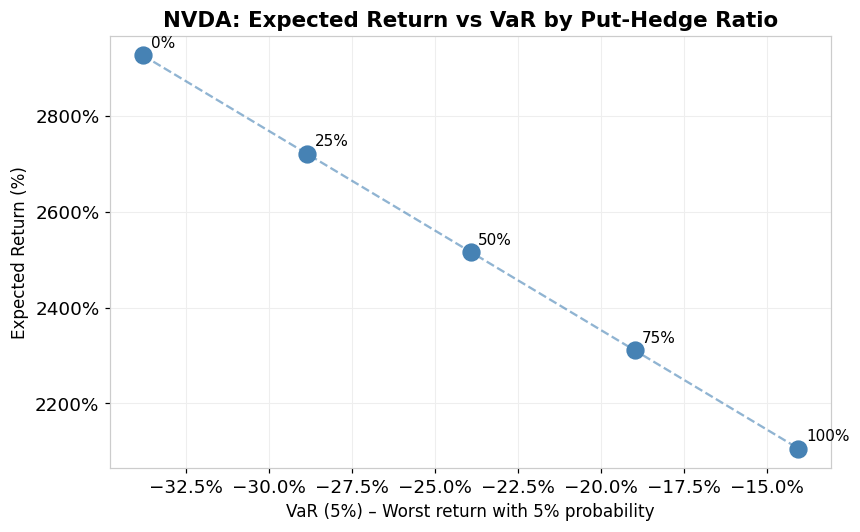

Interpretation: moving right along the x-axis (less negative VaR = lower downside risk)
costs expected return — the classic risk-return trade-off.


In [13]:
# ── Plot: Expected Return vs VaR ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(results_df['_var'], results_df['_exp'] * 100,
           s=120, color='steelblue', zorder=5)
ax.plot(   results_df['_var'], results_df['_exp'] * 100,
           color='steelblue', linewidth=1.5, linestyle='--', alpha=0.6)

for _, row in results_df.iterrows():
    ax.annotate(row['Put-to-Share Ratio'],
                xy=(row['_var'], row['_exp']*100),
                xytext=(5, 5), textcoords='offset points', fontsize=10)

ax.set_xlabel('VaR (5%) – Worst return with 5% probability', fontsize=11)
ax.set_ylabel('Expected Return (%)', fontsize=11)
ax.set_title(f'{TICKER}: Expected Return vs VaR by Put-Hedge Ratio')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

print('Interpretation: moving right along the x-axis (less negative VaR = lower downside risk)')
print('costs expected return — the classic risk-return trade-off.')

---
## Summary

| Topic | Key Takeaway |
|---|---|
| **Latin Hypercube** | Produces a more representative distribution with fewer iterations than pure random sampling |
| **Correlations** | Ignoring correlated inputs leads to incorrect (usually too wide) risk estimates |
| **Tornado Diagrams** | Rank correlations quickly identify the top risk drivers |
| **Scenario Analysis** | Filtering simulation results reveals which input combinations lead to bad outcomes |
| **GBM / Stock Prices** | Log returns calibrated on 5 years of Yahoo Finance data; uncertainty grows like √t |
| **Bootstrapping** | Non-parametric — samples real data directly; automatically handles non-normality |
| **Value at Risk** | A percentile-based risk metric; put hedging truncates the left tail at the cost of expected return |